# Assignment 2a
## Title : Multiclass classification using Deep Neural Networks: Example: Use the OCR letter
recognition dataset https://archive.ics.uci.edu/ml/datasets/letter+recognition


import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


Load and Explore Dataset

In [2]:
# Load the dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/letter-recognition/letter-recognition.data"
column_names = [
    "letter", "x-box", "y-box", "width", "high", "onpix", "x-bar", "y-bar",
    "x2bar", "y2bar", "xybar", "x2ybr", "xy2br", "x-ege", "xegvy", "y-ege", "yegvx"
]
df = pd.read_csv(url, names=column_names)

# Show the first few rows
df.head()


,letter,x-box,y-box,width,high,onpix,x-bar,y-bar,x2bar,y2bar,xybar,x2ybr,xy2br,x-ege,xegvy,y-ege,yegvx
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


Preprocess the Data

In [3]:
# Encode target labels (A-Z)
label_encoder = LabelEncoder()
df['letter'] = label_encoder.fit_transform(df['letter'])

# Split features and target
X = df.drop('letter', axis=1)
y = df['letter']

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)


Build the DNN Model

In [4]:
model = Sequential([
    Dense(128, input_shape=(16,), activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(26, activation='softmax')  # 26 classes (A-Z)
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Train the Model

In [5]:
history = model.fit(X_train, y_train, epochs=30, batch_size=32,
                    validation_split=0.1, verbose=1)

Epoch 1/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.2715 - loss: 2.5387 - val_accuracy: 0.6994 - val_loss: 1.1045
Epoch 2/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.5986 - loss: 1.3017 - val_accuracy: 0.7588 - val_loss: 0.8440
Epoch 3/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6604 - loss: 1.0798 - val_accuracy: 0.7931 - val_loss: 0.7257
Epoch 4/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7049 - loss: 0.9542 - val_accuracy: 0.8181 - val_loss: 0.6441
Epoch 5/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7190 - loss: 0.8787 - val_accuracy: 0.8300 - val_loss: 0.5954
Epoch 6/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7493 - loss: 0.7981 - val_accuracy: 0.8419 - val_loss: 0.5427
Epoch 7/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7632 - loss: 0.7643 - val_accuracy: 0.8531 - val_loss: 0.5023
Epoch 8/30
450/450 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7716 - loss: 0.7179 - val_accuracy: 0.

Evaluate the Model

In [6]:
# Test accuracy
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9307 - loss: 0.2324
Test Accuracy: 0.9300


Plot Training History

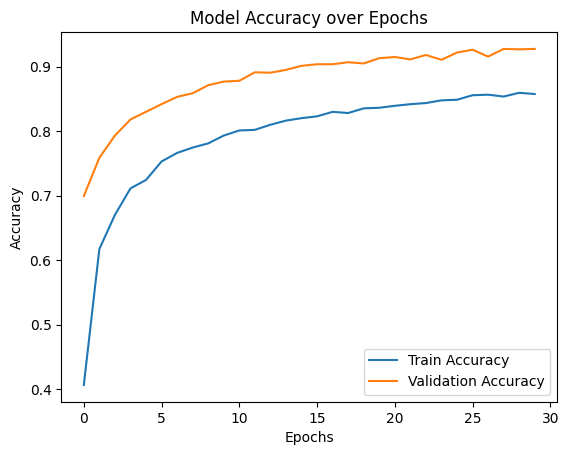

In [7]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Model Accuracy over Epochs")
plt.show()


Classification Report & Confusion Matrix

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

           A       0.97      0.96      0.97       158
           B       0.80      0.89      0.84       153
           C       0.92      0.97      0.94       147
           D       0.94      0.94      0.94       161
           E       0.88      0.94      0.91       154
           F       0.92      0.90      0.91       155
           G       0.93      0.87      0.90       155
           H       0.94      0.84      0.88       147
           I       0.96      0.88      0.92       151
           J       0.93      0.96      0.95       149
           K       0.89      0.94      0.91       148
           L       0.95      0.91      0.93       152
           M       0.99      0.98      0.99       158
           N       0.97      0.92      0.94       157
           O       0.93      0.92      0.93       150
           P       0.93      0.93      0.93       161
           Q       0.94      0.97      0

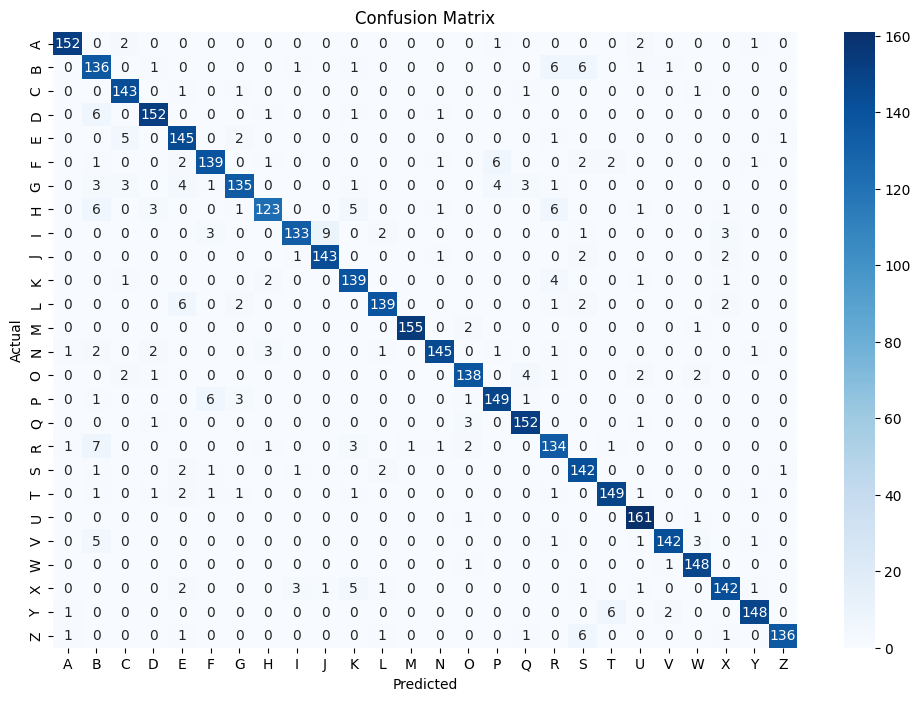

In [8]:
# Predictions
y_pred = np.argmax(model.predict(X_test), axis=-1)

# Report
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Confusion Matrix
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# Conclusion
- The DNN achieved high accuracy in classifying handwritten letters from pixel-based features.
- With proper tuning, dropout, and normalization, deep neural networks perform well for multiclass classification problems.
- Future improvements can include CNNs or ensemble methods.
